# Rilevamento di anomalie IoT industriali con clustering

Questo notebook presenta una pipeline riproducibile di anomaly detection non supervisionata per serie temporali industriali. I dati sono **interamente sintetici**, generati in memoria con seed fisso e senza leggere o trasformare dataset esterni.

Obiettivo: apprendere tre regimi operativi con K-Means e segnalare le osservazioni lontane dal centroide del proprio cluster. Le etichette sintetiche dei guasti vengono usate soltanto alla fine, per valutare il modello: non partecipano a preprocessing, PCA, clustering o calibrazione delle soglie.

## 1. Ambiente e codice del progetto

In locale il notebook usa il repository corrente. Su Kaggle clona il repository GitHub pubblico. Prima della pubblicazione definitiva, `PROJECT_REF` verrà sostituito con un tag immutabile per rendere l'esecuzione riproducibile anche se `main` evolve.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

PROJECT_URL = "https://github.com/cugnatasebastiano81-bit/rilevamento-anomalie-iot-industriale.git"
PROJECT_REF = os.environ.get("IOT_PROJECT_REF", "main")
ON_KAGGLE = Path("/kaggle/working").exists()

if ON_KAGGLE:
    project_root = Path("/kaggle/working/rilevamento-anomalie-iot-industriale")
    if not project_root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", PROJECT_REF, PROJECT_URL, str(project_root)],
            check=True,
        )
else:
    candidates = [Path.cwd(), Path.cwd().parent]
    project_root = next(path for path in candidates if (path / "src").is_dir())

sys.path.insert(0, str(project_root))
print(f"Ambiente: {'Kaggle' if ON_KAGGLE else 'locale'}")
print("Codice: repository GitHub pubblico" if ON_KAGGLE else "Codice: checkout locale del repository")
print(f"Python: {sys.version.split()[0]}")

Ambiente: locale
Codice: checkout locale del repository
Python: 3.13.13


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

from src.anomaly import (
    classify_anomalies,
    compute_centroid_distances,
    compute_cluster_thresholds,
    resolve_row_thresholds,
)
from src.clustering import compute_k_selection_curves, fit_final_kmeans
from src.features import (
    CONTEXT_NUM_COLS,
    add_regime_onehot,
    add_rolling_and_diff,
    derived_feature_cols,
    fit_pca,
    fit_scaler,
    regime_onehot_cols,
)
from src.pipeline import clip_physical_bounds, drop_residual_na, interpolate_per_asset, split_temporal
from src.synthetic_data import SENSOR_COLUMNS, SyntheticIoTConfig, generate_synthetic_iot_data
from src.validation import build_fault_targets, classification_metrics

SEED = 20260825
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False})

## 2. Dataset sintetico e controlli di qualità

Il generatore simula 16 asset per 10 giorni, al minuto. I tre regimi rappresentano standby, produzione ad alta velocità e produzione ad alto carico. Quattro famiglie di guasto introducono derive, oscillazioni, surriscaldamenti e urti. Una parte delle etichette positive viene deliberatamente omessa per simulare annotazioni incomplete.

In [3]:
config = SyntheticIoTConfig(seed=SEED)
df = generate_synthetic_iot_data(config)

summary = pd.Series({
    "righe": len(df),
    "colonne": len(df.columns),
    "asset": df["asset_id"].nunique(),
    "inizio": df["timestamp"].min(),
    "fine": df["timestamp"].max(),
    "missing sensori": f"{df[SENSOR_COLUMNS].isna().to_numpy().mean():.3%}",
    "righe con fault noto": f"{(df['fault_code_true'] != 0).mean():.3%}",
    "annotazioni positive parziali": f"{df['anomaly_label'].mean():.3%}",
    "seed": SEED,
})
assert len(df) == 230_400
assert not df.duplicated(["asset_id", "timestamp"]).any()
display(summary.to_frame("valore"))
display(df.head(3))

,valore
righe,230400
colonne,19
asset,16
inizio,2025-02-01 00:00:00+00:00
fine,2025-02-10 23:59:00+00:00
missing sensori,0.380%
righe con fault noto,3.750%
annotazioni positive parziali,2.244%
seed,20260825


,timestamp,asset_id,site_id,line_id,regime,ambient_temp_c,humidity_pct,load_pct,rpm,current_a,pressure_bar,flow_lpm,temp_c,vib_rms,vib_crest,vib_kurtosis,fault_code_true,fault_type_true,anomaly_label
0,2025-02-01 00:00:00+00:00,1,S01,L01,0,15.885093,72.214011,90.753254,1638.248714,29.300160,8.241721,57.965690,57.364828,1.331053,2.619511,4.975386,0,none,0
1,2025-02-01 00:01:00+00:00,1,S01,L01,0,16.683667,69.361118,87.963905,1673.051366,27.996069,8.062762,62.346135,58.642516,1.267950,2.942104,5.088439,0,none,0
2,2025-02-01 00:02:00+00:00,1,S01,L01,0,16.399016,72.473681,87.780079,1666.860709,28.922753,8.030340,62.367852,58.210626,1.246035,2.706831,4.498937,0,none,0


,load_pct,rpm,current_a,temp_c,vib_rms
regime,,,,,
0,8.84,119.22,2.78,22.54,0.23
1,44.23,2621.44,13.76,44.69,0.64
2,90.54,1759.18,29.89,64.44,1.39


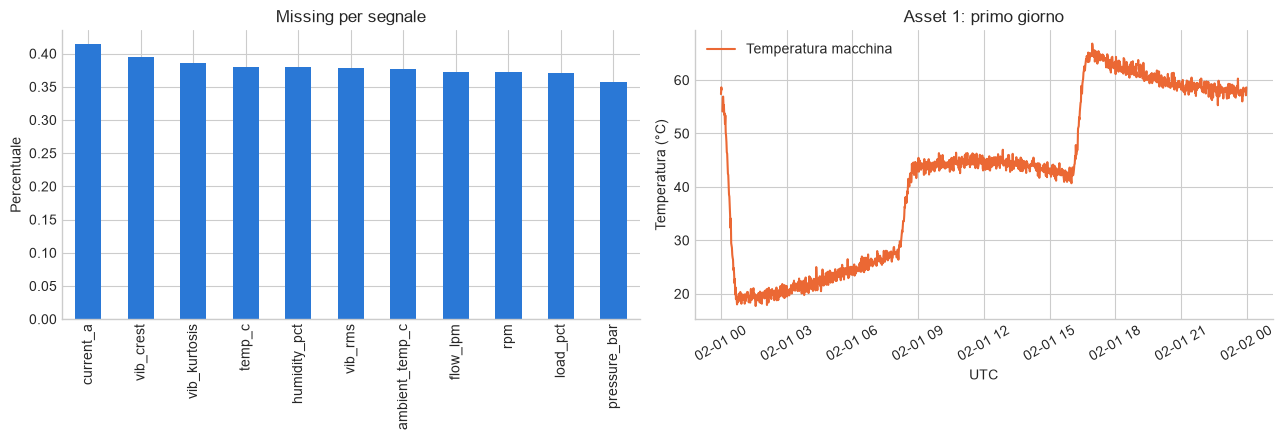

In [4]:
profile_columns = ["load_pct", "rpm", "current_a", "temp_c", "vib_rms"]
display(df.groupby("regime")[profile_columns].median().round(2).rename_axis("regime"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
missing_pct = 100 * df[SENSOR_COLUMNS].isna().mean().sort_values(ascending=False)
missing_pct.plot.bar(ax=axes[0], color="#2a78d6")
axes[0].set(title="Missing per segnale", ylabel="Percentuale", xlabel="")

asset = df[(df["asset_id"] == 1) & (df["timestamp"] < df["timestamp"].min() + pd.Timedelta(days=1))]
axes[1].plot(asset["timestamp"], asset["temp_c"], label="Temperatura macchina", color="#eb6834")
axes[1].set(title="Asset 1: primo giorno", ylabel="Temperatura (°C)", xlabel="UTC")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Split temporale e feature engineering senza leakage

Lo split avviene prima dell'interpolazione. Train e test vengono interpolati separatamente e ogni operazione con `fit` usa soltanto il train. Le feature includono contesto, one-hot del regime e statistiche mobili per asset su 15 minuti.

In [5]:
df, bounds_report = clip_physical_bounds(df)
test_start = df["timestamp"].min() + pd.Timedelta(days=7)
train_end = test_start - pd.Timedelta(minutes=1)
train, test = split_temporal(df, train_end=train_end, test_start=test_start)
train = drop_residual_na(interpolate_per_asset(train))
test = drop_residual_na(interpolate_per_asset(test))

regime_categories = sorted(train["regime"].unique())
train_feat = add_rolling_and_diff(add_regime_onehot(train, regime_categories))
test_feat = add_rolling_and_diff(add_regime_onehot(test, regime_categories))
feature_columns = regime_onehot_cols(regime_categories) + CONTEXT_NUM_COLS + derived_feature_cols()
train_feat = train_feat.dropna(subset=feature_columns).reset_index(drop=True)
test_feat = test_feat.dropna(subset=feature_columns).reset_index(drop=True)

print(f"Train: {len(train_feat):,} righe | Test: {len(test_feat):,} righe")
print(f"Feature: {len(feature_columns)} | Label usate come feature: 0")

Train: 160,678 righe | Test: 68,702 righe
Feature: 30 | Label usate come feature: 0


## 4. PCA e K-Means

Il progetto mantiene `K=3` per rappresentare i tre regimi operativi. La diagnostica fino a K=6 è riportata per trasparenza: massimizzare la silhouette non è l'unico criterio, perché cluster aggiuntivi tendono a isolare transizioni o guasti invece di descrivere stati operativi stabili.

In [6]:
scaler = fit_scaler(train_feat, feature_columns)
X_train = scaler.transform(train_feat[feature_columns])
X_test = scaler.transform(test_feat[feature_columns])
pca = fit_pca(X_train, n_components=10, random_state=SEED)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

diagnostics = compute_k_selection_curves(X_train_pca, range(2, 7), sample_size=5_000, random_state=SEED)
diagnostics_df = pd.DataFrame(diagnostics)
display(diagnostics_df.round(4))

kmeans = fit_final_kmeans(X_train_pca, n_clusters=3, random_state=SEED, n_init=10)
train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_pca)
train_feat["cluster"] = train_labels
test_feat["cluster"] = test_labels

cluster_summary = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts(normalize=True).sort_index(),
    "test": pd.Series(test_labels).value_counts(normalize=True).sort_index(),
})
cluster_summary.index.name = "cluster"
nmi = normalized_mutual_info_score(train_feat["regime"], train_labels)
display((100 * cluster_summary).round(2).rename(columns={"train": "train %", "test": "test %"}))
print(f"Varianza spiegata da 10 componenti: {pca.explained_variance_ratio_.sum():.2%}")
print(f"NMI cluster-regime sul train: {nmi:.3f}")

,k,inertia,silhouette
0,2,3.068782e+06,0.3829
1,3,2.395838e+06,0.4170
2,4,1.824126e+06,0.4603
3,5,1.416249e+06,0.4736
4,6,1.288831e+06,0.4749


,train %,test %
cluster,,
0,33.41,33.31
1,33.38,33.44
2,33.21,33.25


Varianza spiegata da 10 componenti: 90.98%
NMI cluster-regime sul train: 0.822


## 5. Distanza dal centroide, soglie e valutazione

La soglia operativa è il 99° percentile della distanza nel train, calcolato separatamente per cluster. Il test viene soltanto trasformato e confrontato con soglie già fissate. `fault_code_true` e `anomaly_label` entrano in gioco solo ora.

In [7]:
train_distance = compute_centroid_distances(X_train_pca, train_labels, kmeans.cluster_centers_)
test_distance = compute_centroid_distances(X_test_pca, test_labels, kmeans.cluster_centers_)
thresholds = compute_cluster_thresholds(train_distance, train_labels, n_clusters=3, percentile=99)
test_threshold = resolve_row_thresholds(test_labels, thresholds["per_cluster_threshold"])
alerts = classify_anomalies(test_distance, test_threshold).astype(int)
fault_known, anomaly_partial = build_fault_targets(test_feat["fault_code_true"], test_feat["anomaly_label"])

metrics_known = classification_metrics(fault_known, alerts)
metrics_partial = classification_metrics(anomaly_partial, alerts)
metrics_table = pd.DataFrame([metrics_known, metrics_partial], index=["fault noto", "label parziale"])[
    ["precision", "recall", "f1", "alert_rate", "tp", "fp", "fn", "tn"]
]
display(metrics_table.round(4))
print("Soglie P99 per cluster:", {k: round(v, 4) for k, v in thresholds["per_cluster_threshold"].items()})
print(f"Alert sul test: {alerts.sum():,} / {len(alerts):,} ({alerts.mean():.3%})")

,precision,recall,f1,alert_rate,tp,fp,fn,tn
fault noto,0.8663,0.1703,0.2847,0.0071,421,65,2051,66165
label parziale,0.5494,0.1765,0.2671,0.0071,267,219,1246,66970


Soglie P99 per cluster: {0: 13.4214, 1: 14.9798, 2: 14.9526}
Alert sul test: 486 / 68,702 (0.707%)


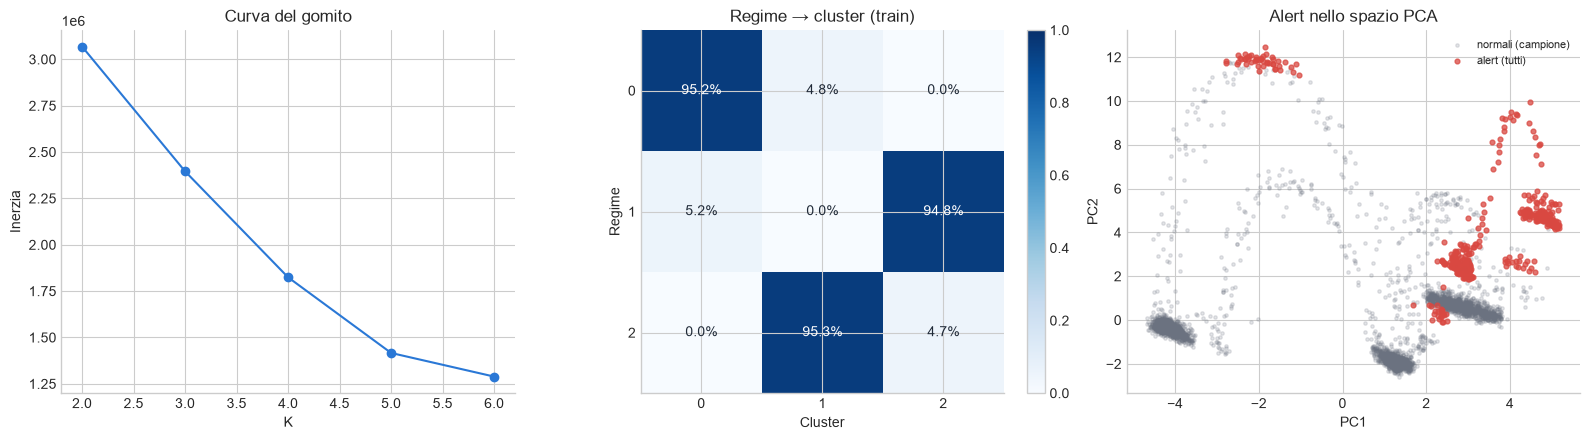

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(diagnostics_df["k"], diagnostics_df["inertia"], marker="o", color="#2a78d6")
axes[0].set(title="Curva del gomito", xlabel="K", ylabel="Inerzia")

cross = pd.crosstab(train_feat["regime"], train_feat["cluster"], normalize="index")
image = axes[1].imshow(cross, vmin=0, vmax=1, cmap="Blues")
axes[1].set(title="Regime → cluster (train)", xlabel="Cluster", ylabel="Regime")
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
for row in range(3):
    for column in range(3):
        value = cross.iloc[row, column]
        axes[1].text(column, row, f"{value:.1%}", ha="center", va="center", color="white" if value > 0.5 else "#1f2937")
fig.colorbar(image, ax=axes[1], fraction=0.046)

rng = np.random.default_rng(SEED)
background = np.flatnonzero(alerts == 0)
sample = rng.choice(background, size=min(4_000, len(background)), replace=False)
axes[2].scatter(X_test_pca[sample, 0], X_test_pca[sample, 1], s=6, alpha=0.18, color="#6b7280", label="normali (campione)")
axes[2].scatter(X_test_pca[alerts == 1, 0], X_test_pca[alerts == 1, 1], s=12, alpha=0.75, color="#d94841", label="alert (tutti)")
axes[2].set(title="Alert nello spazio PCA", xlabel="PC1", ylabel="PC2")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Conclusioni e limiti

La pipeline identifica tre stati operativi bilanciati e produce alert ad alta precisione rispetto ai guasti sintetici noti. Il richiamo rimane volutamente limitato dalla soglia P99: è il principale compromesso operativo da discutere, non un risultato da nascondere.

Questo è un benchmark didattico su dati sintetici, non una validazione su un impianto reale. Prima di un uso industriale servirebbero dati reali, revisione degli esperti di dominio, costi espliciti di falsi positivi e falsi negativi, monitoraggio del drift e una procedura di ricalibrazione controllata. Il repository completo, i test e la documentazione sono disponibili su [GitHub](https://github.com/cugnatasebastiano81-bit/rilevamento-anomalie-iot-industriale).